# 04 - Smoothing Exploration

Two-phase notebook:
1. **Phase 1** -- visually compare smoothing parameter variants, then confirm with a quick reconstruction test. Pick one winner per method.
2. **Phase 2** -- generate features for all bases x winning smoothing configs x K values.

In [43]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ROOT = Path.cwd()
SCRIPT_PATH = ROOT / "02_generate_basis_features.py"
sys.modules.pop("bp_basis_step02", None)
spec = spec_from_file_location("bp_basis_step02", SCRIPT_PATH)
step02 = module_from_spec(spec)
assert spec.loader is not None
sys.modules[spec.name] = step02
spec.loader.exec_module(step02)

from _common import BP_SAMPLED_CSV, FEATURES_DIR, RESULTS_DIR, RP_SAMPLED_CSV, flatten_feature_blocks, l2_normalize

In [19]:
bp = step02.load_block(BP_SAMPLED_CSV)
rp = step02.load_block(RP_SAMPLED_CSV)
step02.check_alignment(bp, rp)
preview_idx = step02.choose_example_indices(bp.labels, n_examples=4)

print("BP:", bp.flux.shape)
print("RP:", rp.flux.shape)

BP: (2815, 154)
RP: (2815, 193)


---
## Phase 1: Tune smoothing parameters

We use a single representative basis and fixed K to evaluate smoothing variants.
Change `EVAL_BASIS` and `EVAL_K` if needed.

In [31]:
EVAL_BASIS = "bspline"
EVAL_K = 20

SMOOTHING_PARAMS = {
    "savgol": [
        {"window_length": 5, "polyorder": 2},
        {"window_length": 7, "polyorder": 2},
        {"window_length": 7, "polyorder": 3},
        {"window_length": 11, "polyorder": 2},
        {"window_length": 11, "polyorder": 3},
        {"window_length": 15, "polyorder": 3},
        {"window_length": 21, "polyorder": 3},
        {"window_length": 31, "polyorder": 3},
        {"window_length": 41, "polyorder": 3}
    ],
    "gaussian": [
        {"sigma": 0.5},
        {"sigma": 1.0},
        {"sigma": 2.0},
        {"sigma": 3.0},
        {"sigma": 5.0},
        {"sigma": 10.0},
        {"sigma": 20.0},
        {"sigma": 30.0},
    ],
    "spline": [
        {"s_factor": 0.001},
        {"s_factor": 0.01},
        {"s_factor": 0.05},
        {"s_factor": 0.1},
        {"s_factor": 0.2},
    ],
}

### Step A: Visual comparison -- raw vs smoothed flux

For each smoothing method, overlay the raw spectrum and several parameter variants on a few example stars.

In [32]:
example_stars = preview_idx[:3]

for method, param_list in SMOOTHING_PARAMS.items():
    n_stars = len(example_stars)
    n_rows = n_stars * 2
    subplot_titles = []
    for star_idx in example_stars:
        for block, arm_label in [(bp, "BP"), (rp, "RP")]:
            subplot_titles.append(f"{arm_label} -- source_id={int(block.source_ids[star_idx])}")

    fig = make_subplots(rows=n_rows, cols=1, subplot_titles=subplot_titles, vertical_spacing=0.06)

    import plotly.express as px
    palette = px.colors.qualitative.Plotly
    param_colors = {}
    for i, params in enumerate(param_list):
        tag = ", ".join(f"{k}={v}" for k, v in params.items())
        param_colors[tag] = palette[i % len(palette)]

    for star_i, star_idx in enumerate(example_stars):
        for arm_i, (block, arm_label) in enumerate([(bp, "BP"), (rp, "RP")]):
            row = star_i * 2 + arm_i + 1
            raw_flux = block.flux[star_idx]
            show_legend = star_i == 0 and arm_i == 0

            fig.add_trace(go.Scatter(
                x=block.wavelengths, y=raw_flux,
                mode="lines", name="raw",
                line=dict(color="black", width=1.8),
                opacity=0.7, legendgroup="raw", showlegend=show_legend,
            ), row=row, col=1)

            for params in param_list:
                smoothed = step02.smooth_flux(raw_flux, method, **params)
                tag = ", ".join(f"{k}={v}" for k, v in params.items())
                fig.add_trace(go.Scatter(
                    x=block.wavelengths, y=smoothed,
                    mode="lines", name=tag,
                    line=dict(width=1.2, color=param_colors[tag]),
                    opacity=0.8, legendgroup=tag, showlegend=show_legend,
                ), row=row, col=1)

    fig.update_layout(
        title_text=f"Smoothing method: {method}",
        height=350 * n_rows,
        template="plotly_white",
    )
    fig.show()

### Step B: Reconstruction confirmation

For each smoothing method + param variant, fit the evaluation basis at the evaluation K
and compute reconstruction R-squared and rel-L2 on `bp_rp_combined`.

In [33]:
tuning_rows = []

for method, param_list in SMOOTHING_PARAMS.items():
    for params in param_list:
        tag = "_".join(f"{k}{v}" for k, v in params.items())
        bp_fit = step02.build_block_fit(bp, EVAL_BASIS, method, EVAL_K, **params)
        rp_fit = step02.build_block_fit(rp, EVAL_BASIS, method, EVAL_K, **params)

        combined_raw = np.hstack([bp.flux, rp.flux])
        combined_recon = np.hstack([bp_fit.reconstructed_flux, rp_fit.reconstructed_flux])
        metrics = step02.compute_metric_arrays(combined_raw, combined_recon)

        tuning_rows.append({
            "method": method,
            "params": str(params),
            "tag": tag,
            "rel_l2_mean": float(metrics["rel_l2"].mean()),
            "rel_l2_std": float(metrics["rel_l2"].std()),
            "r2_mean": float(metrics["r2"].mean()),
            "r2_std": float(metrics["r2"].std()),
            "rmse_mean": float(metrics["rmse"].mean()),
        })

# add none baseline
bp_fit_none = step02.build_block_fit(bp, EVAL_BASIS, "none", EVAL_K)
rp_fit_none = step02.build_block_fit(rp, EVAL_BASIS, "none", EVAL_K)
combined_raw = np.hstack([bp.flux, rp.flux])
combined_recon_none = np.hstack([bp_fit_none.reconstructed_flux, rp_fit_none.reconstructed_flux])
metrics_none = step02.compute_metric_arrays(combined_raw, combined_recon_none)
tuning_rows.append({
    "method": "none",
    "params": "{}",
    "tag": "baseline",
    "rel_l2_mean": float(metrics_none["rel_l2"].mean()),
    "rel_l2_std": float(metrics_none["rel_l2"].std()),
    "r2_mean": float(metrics_none["r2"].mean()),
    "r2_std": float(metrics_none["r2"].std()),
    "rmse_mean": float(metrics_none["rmse"].mean()),
})

tuning_df = pd.DataFrame(tuning_rows).sort_values("rel_l2_mean")
display(tuning_df)

,method,params,tag,rel_l2_mean,rel_l2_std,r2_mean,r2_std,rmse_mean
22,none,{},baseline,0.041521,0.021310,0.988795,0.014196,0.003152
0,savgol,"{'window_length': 5, 'polyorder': 2}",window_length5_polyorder2,0.041523,0.021310,0.988794,0.014197,0.003152
2,savgol,"{'window_length': 7, 'polyorder': 3}",window_length7_polyorder3,0.041526,0.021312,0.988792,0.014199,0.003153
9,gaussian,{'sigma': 0.5},sigma0.5,0.041526,0.021312,0.988792,0.014199,0.003153
1,savgol,"{'window_length': 7, 'polyorder': 2}",window_length7_polyorder2,0.041543,0.021320,0.988784,0.014211,0.003154
4,savgol,"{'window_length': 11, 'polyorder': 3}",window_length11_polyorder3,0.041544,0.021320,0.988783,0.014209,0.003154
5,savgol,"{'window_length': 15, 'polyorder': 3}",window_length15_polyorder3,0.041597,0.021337,0.988756,0.014236,0.003158
10,gaussian,{'sigma': 1.0},sigma1.0,0.041602,0.021349,0.988753,0.014242,0.003158
3,savgol,"{'window_length': 11, 'polyorder': 2}",window_length11_polyorder2,0.041709,0.021367,0.988703,0.014296,0.003167
6,savgol,"{'window_length': 21, 'polyorder': 3}",window_length21_polyorder3,0.042222,0.021613,0.988432,0.014587,0.003205


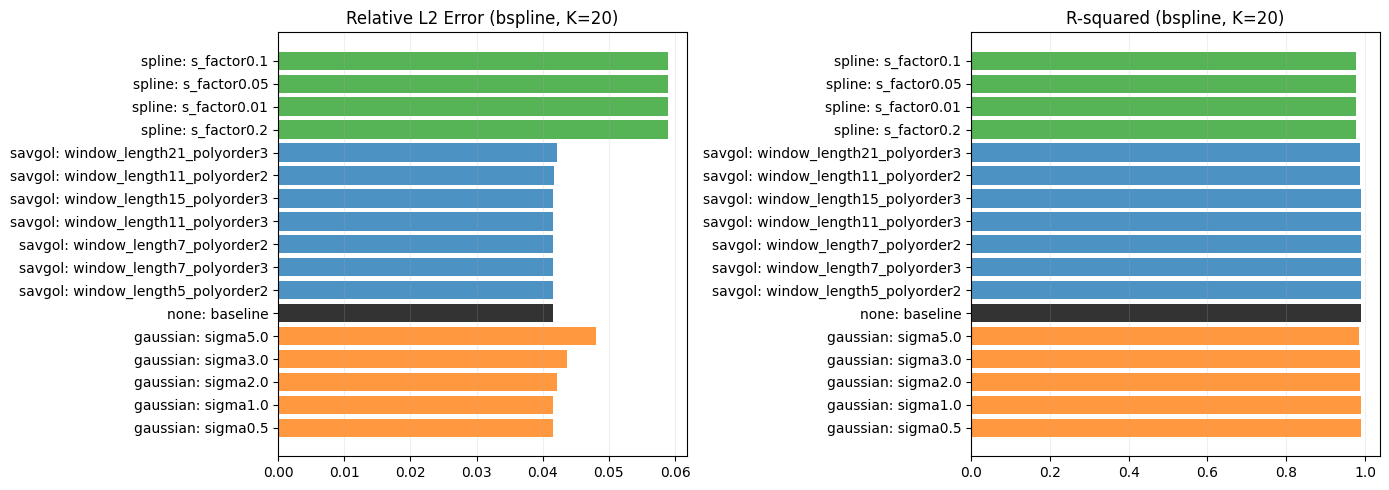

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_colors = {"none": "black", "savgol": "#1f77b4", "gaussian": "#ff7f0e", "spline": "#2ca02c"}

for ax, metric, title in [
    (axes[0], "rel_l2_mean", f"Relative L2 Error ({EVAL_BASIS}, K={EVAL_K})"),
    (axes[1], "r2_mean", f"R-squared ({EVAL_BASIS}, K={EVAL_K})"),
]:
    for method, grp in tuning_df.groupby("method"):
        ax.barh(
            [f"{method}: {row['tag']}" for _, row in grp.iterrows()],
            grp[metric],
            color=method_colors.get(method, "gray"),
            alpha=0.8,
        )
    ax.set_title(title)
    ax.grid(alpha=0.2, axis="x")

fig.tight_layout()
plt.show()

### Pick winners

Based on the visual inspection and reconstruction metrics above, set the winning parameters below.
Edit the values after reviewing the plots.

In [34]:
WINNING_PARAMS = {
    "savgol": {"window_length": 41, "polyorder": 3},
    "gaussian": {"sigma": 5.0},
    "spline": {"s_factor": 0.001},
}

print("Selected smoothing parameters:")
for method, params in WINNING_PARAMS.items():
    print(f"  {method}: {params}")

Selected smoothing parameters:
  savgol: {'window_length': 41, 'polyorder': 3}
  gaussian: {'sigma': 5.0}
  spline: {'s_factor': 0.001}


---
## Phase 2: Generate features with winning smoothing configs

Full grid: 3 bases x 4 smoothing settings (none + 3 winners) x 8 K values.

In [35]:
bases = ["chebyshev", "legendre", "bspline"]
k_list = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

smoothing_configs = {"none": {}}
smoothing_configs.update(WINNING_PARAMS)

reconstruction_dir = RESULTS_DIR / "reconstruction_smoothed"
reconstruction_dir.mkdir(parents=True, exist_ok=True)

metric_frames = []
generated = []

for basis in bases:
    for smoothing, smooth_kwargs in smoothing_configs.items():
        for K in k_list:
            print(f"basis={basis:10s} smoothing={smoothing:8s} K={K:02d}")
            bp_fit = step02.build_block_fit(bp, basis, smoothing, K, **smooth_kwargs)
            rp_fit = step02.build_block_fit(rp, basis, smoothing, K, **smooth_kwargs)

            feat_df = flatten_feature_blocks(bp.source_ids, bp.labels, bp_fit.coeffs, rp_fit.coeffs)
            coeff_cols = [c for c in feat_df.columns if c.startswith("c")]
            feat_df = l2_normalize(feat_df, coeff_cols=coeff_cols)
            out_path = FEATURES_DIR / f"{basis}_{smoothing}_{K:02d}_L2.csv"
            feat_df.to_csv(out_path, index=False)
            generated.append(out_path.name)

            metric_frames.append(
                step02.metric_frame(
                    bp, arm="bp", basis=basis, smoothing=smoothing,
                    n_coeffs=K, smoothed_flux=bp_fit.smoothed_flux,
                    reconstructed_flux=bp_fit.reconstructed_flux,
                )
            )
            metric_frames.append(
                step02.metric_frame(
                    rp, arm="rp", basis=basis, smoothing=smoothing,
                    n_coeffs=K, smoothed_flux=rp_fit.smoothed_flux,
                    reconstructed_flux=rp_fit.reconstructed_flux,
                )
            )
            metric_frames.append(
                step02.combined_metric_frame(
                    bp, rp, basis=basis, smoothing=smoothing, n_coeffs=K,
                    bp_smoothed_flux=bp_fit.smoothed_flux,
                    rp_smoothed_flux=rp_fit.smoothed_flux,
                    bp_reconstructed_flux=bp_fit.reconstructed_flux,
                    rp_reconstructed_flux=rp_fit.reconstructed_flux,
                )
            )

raw_metrics = pd.concat(metric_frames, ignore_index=True)
summary = step02.summarize_metric_frame(raw_metrics)

raw_metrics.to_csv(reconstruction_dir / "reconstruction_metrics_by_star.csv", index=False)
summary.to_csv(reconstruction_dir / "reconstruction_summary.csv", index=False)

combined_ranking = step02.rank_combined_configs(summary)
combined_ranking.to_csv(reconstruction_dir / "reconstruction_summary_combined_ranked.csv", index=False)

print(f"\nGenerated {len(generated)} feature files")
print(f"Saved reconstruction results to {reconstruction_dir}")

basis=chebyshev  smoothing=none     K=05
basis=chebyshev  smoothing=none     K=10
basis=chebyshev  smoothing=none     K=15
basis=chebyshev  smoothing=none     K=20
basis=chebyshev  smoothing=none     K=25
basis=chebyshev  smoothing=none     K=30
basis=chebyshev  smoothing=none     K=35
basis=chebyshev  smoothing=none     K=40
basis=chebyshev  smoothing=none     K=45
basis=chebyshev  smoothing=none     K=50
basis=chebyshev  smoothing=savgol   K=05
basis=chebyshev  smoothing=savgol   K=10
basis=chebyshev  smoothing=savgol   K=15
basis=chebyshev  smoothing=savgol   K=20
basis=chebyshev  smoothing=savgol   K=25
basis=chebyshev  smoothing=savgol   K=30
basis=chebyshev  smoothing=savgol   K=35
basis=chebyshev  smoothing=savgol   K=40
basis=chebyshev  smoothing=savgol   K=45
basis=chebyshev  smoothing=savgol   K=50
basis=chebyshev  smoothing=gaussian K=05
basis=chebyshev  smoothing=gaussian K=10
basis=chebyshev  smoothing=gaussian K=15
basis=chebyshev  smoothing=gaussian K=20
basis=chebyshev 

### Reconstruction ranking (BP+RP combined)

In [36]:
display(combined_ranking.head(20))

,index,arm,basis,smoothing,n_coeffs,rmse_to_raw_mean,rmse_to_raw_std,mae_to_raw_mean,mae_to_raw_std,rel_l2_to_raw_mean,...,r2_to_raw_mean,r2_to_raw_std,rmse_to_smoothed_mean,rmse_to_smoothed_std,mae_to_smoothed_mean,mae_to_smoothed_std,rel_l2_to_smoothed_mean,rel_l2_to_smoothed_std,r2_to_smoothed_mean,r2_to_smoothed_std
0,139,bp_rp_combined,bspline,none,50,0.001503,0.000909,0.000653,0.000374,0.019796,...,0.997202,0.004347,0.001503,0.000909,0.000653,0.000374,0.019796,0.011978,0.997202,0.004347
1,179,bp_rp_combined,chebyshev,none,50,0.001524,0.000921,0.000907,0.000535,0.020072,...,0.997129,0.004339,0.001524,0.000921,0.000907,0.000535,0.020072,0.012129,0.997129,0.004339
2,219,bp_rp_combined,legendre,none,50,0.001524,0.000921,0.000907,0.000535,0.020072,...,0.997129,0.004339,0.001524,0.000921,0.000907,0.000535,0.020072,0.012129,0.997129,0.004339
3,138,bp_rp_combined,bspline,none,45,0.001785,0.001038,0.000851,0.000482,0.023515,...,0.996145,0.005689,0.001785,0.001038,0.000851,0.000482,0.023515,0.013674,0.996145,0.005689
4,178,bp_rp_combined,chebyshev,none,45,0.001814,0.001019,0.001107,0.000618,0.023894,...,0.996083,0.005563,0.001814,0.001019,0.001107,0.000618,0.023894,0.013425,0.996083,0.005563
5,218,bp_rp_combined,legendre,none,45,0.001814,0.001019,0.001107,0.000618,0.023894,...,0.996083,0.005563,0.001814,0.001019,0.001107,0.000618,0.023894,0.013425,0.996083,0.005563
6,137,bp_rp_combined,bspline,none,40,0.002034,0.001128,0.001048,0.000586,0.026797,...,0.995116,0.006772,0.002034,0.001128,0.001048,0.000586,0.026797,0.014855,0.995116,0.006772
7,177,bp_rp_combined,chebyshev,none,40,0.002086,0.001110,0.001293,0.000689,0.027474,...,0.994954,0.006803,0.002086,0.001110,0.001293,0.000689,0.027474,0.014622,0.994954,0.006803
8,217,bp_rp_combined,legendre,none,40,0.002086,0.001110,0.001293,0.000689,0.027474,...,0.994954,0.006803,0.002086,0.001110,0.001293,0.000689,0.027474,0.014622,0.994954,0.006803
9,136,bp_rp_combined,bspline,none,35,0.002247,0.001219,0.001250,0.000687,0.029593,...,0.994111,0.007931,0.002247,0.001219,0.001250,0.000687,0.029593,0.016059,0.994111,0.007931


Saved metric plots: ['bp_rmse_to_raw_mean.png', 'bp_rel_l2_to_raw_mean.png', 'bp_r2_to_raw_mean.png', 'rp_rmse_to_raw_mean.png', 'rp_rel_l2_to_raw_mean.png', 'rp_r2_to_raw_mean.png', 'bp_rp_combined_rmse_to_raw_mean.png', 'bp_rp_combined_rel_l2_to_raw_mean.png', 'bp_rp_combined_r2_to_raw_mean.png']


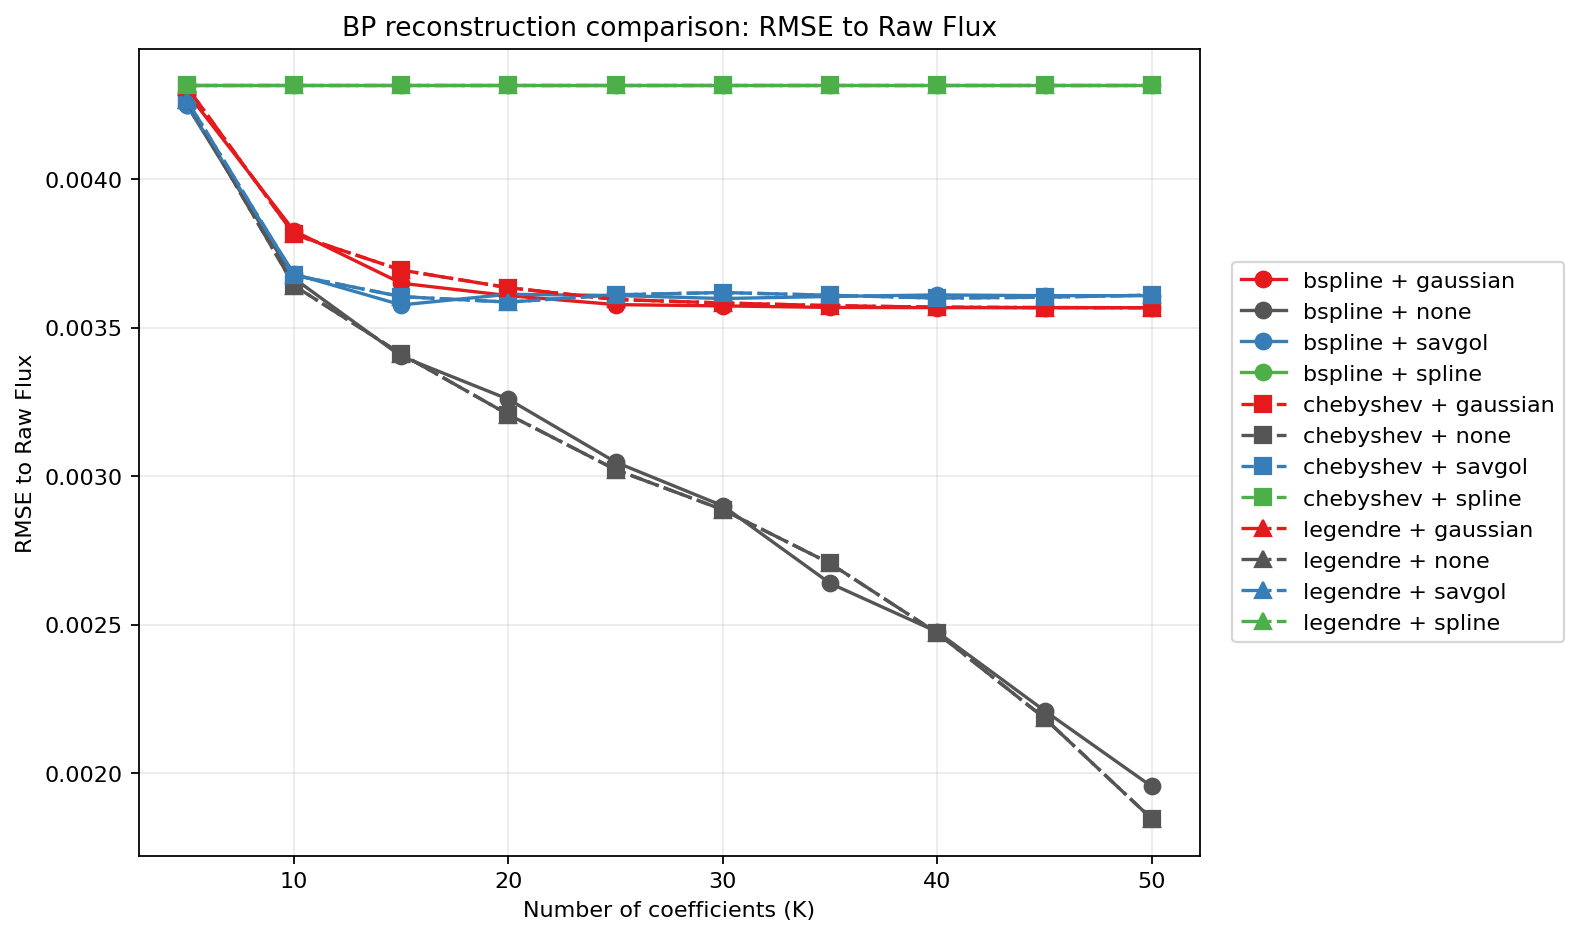

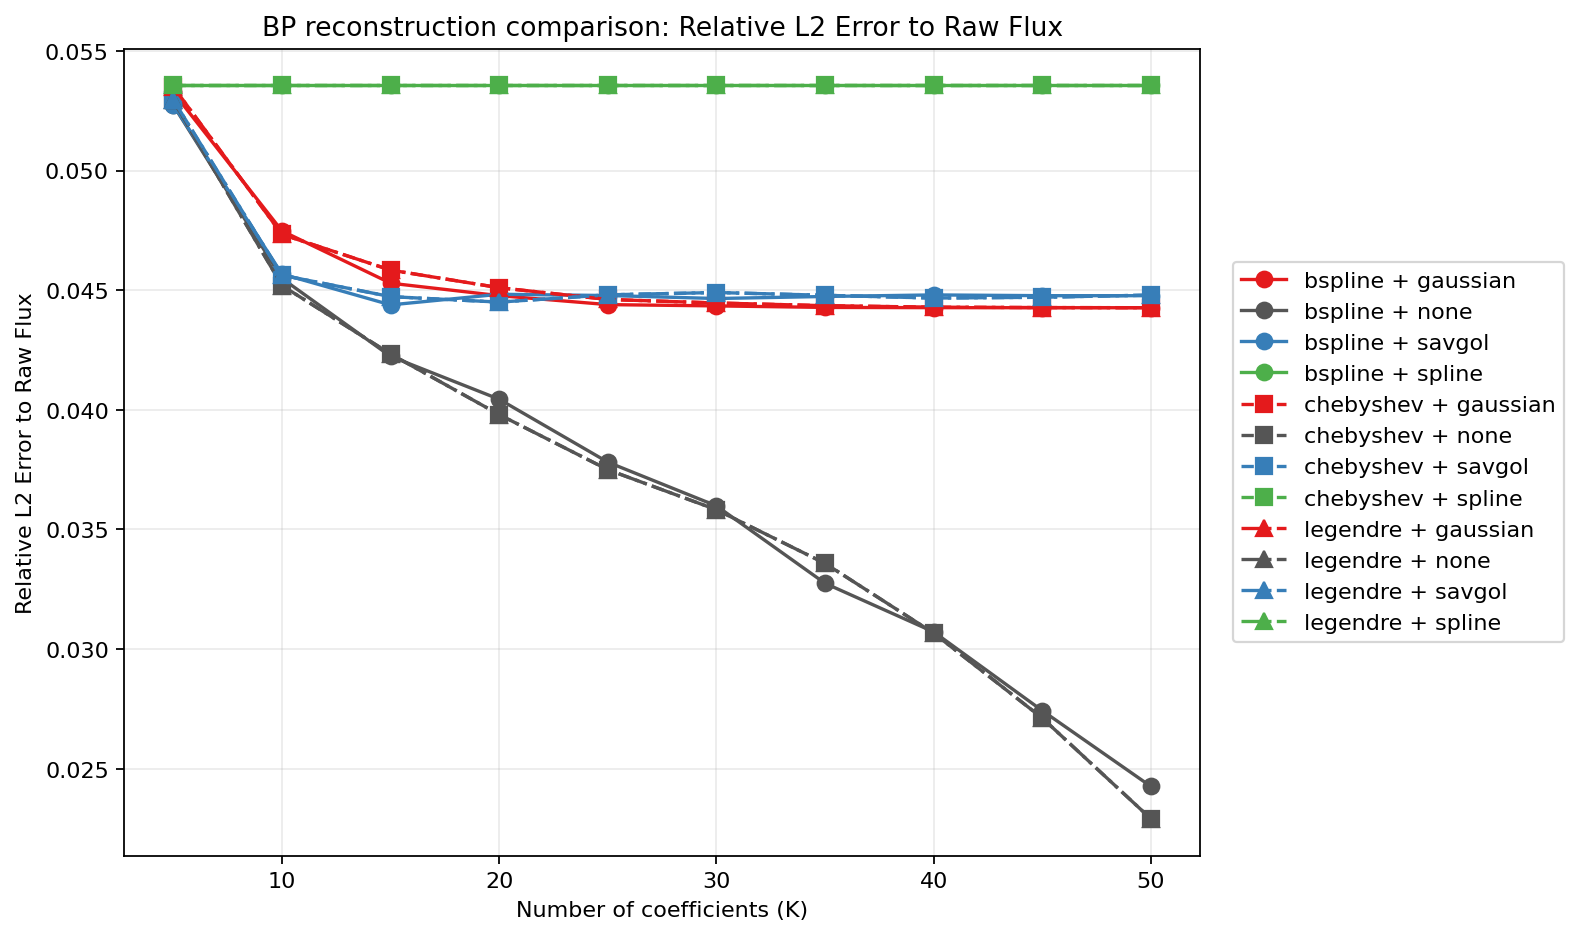

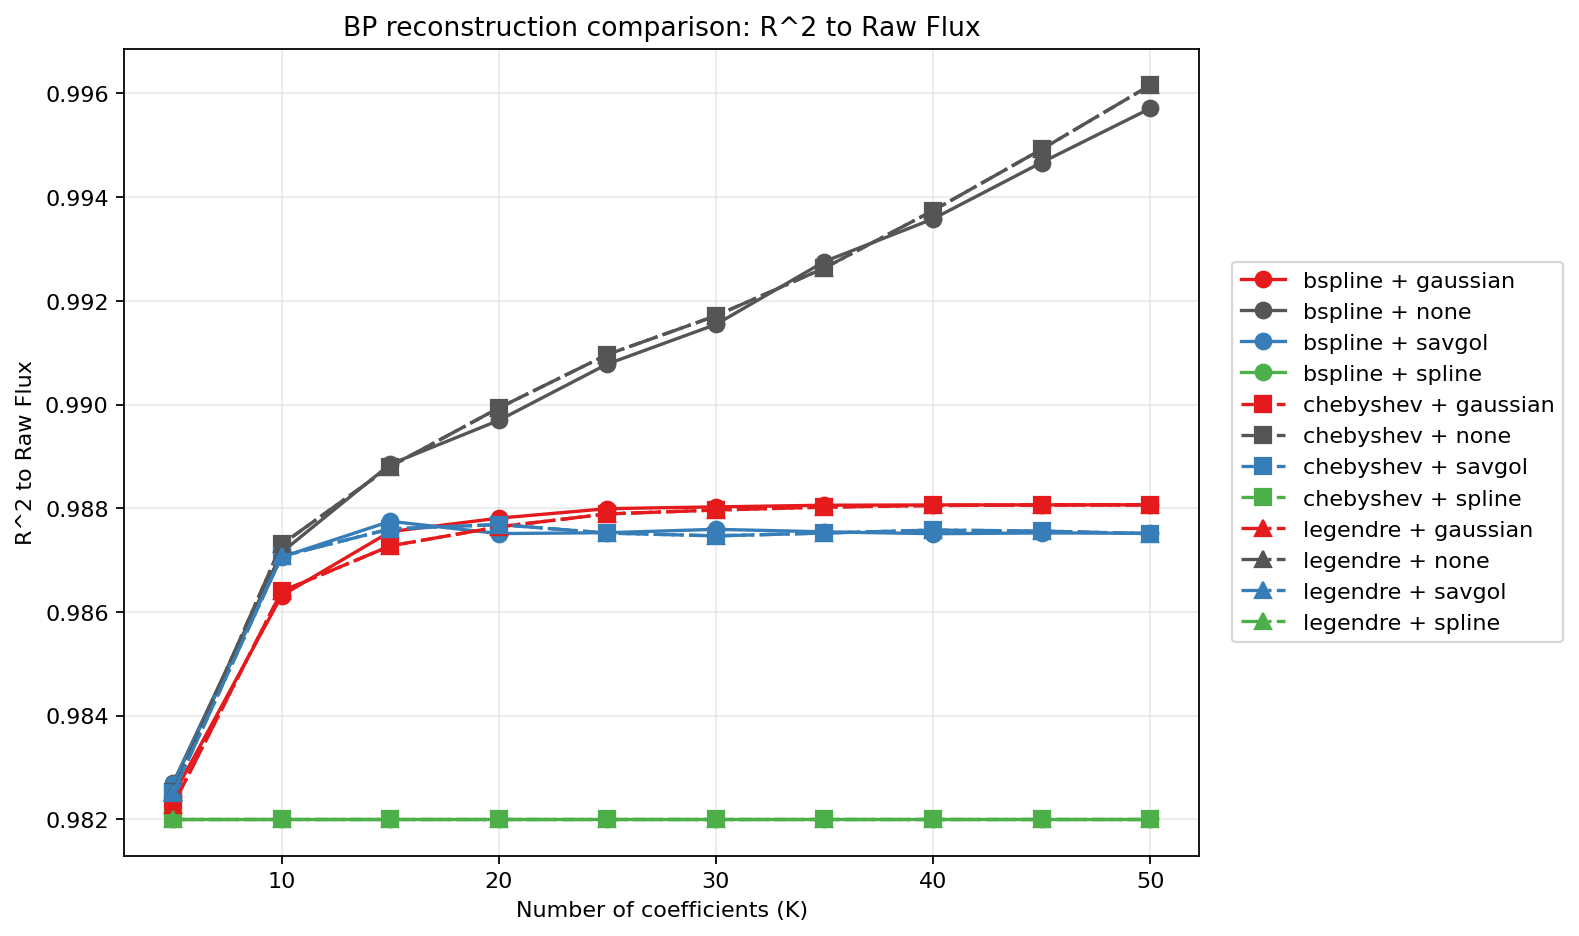

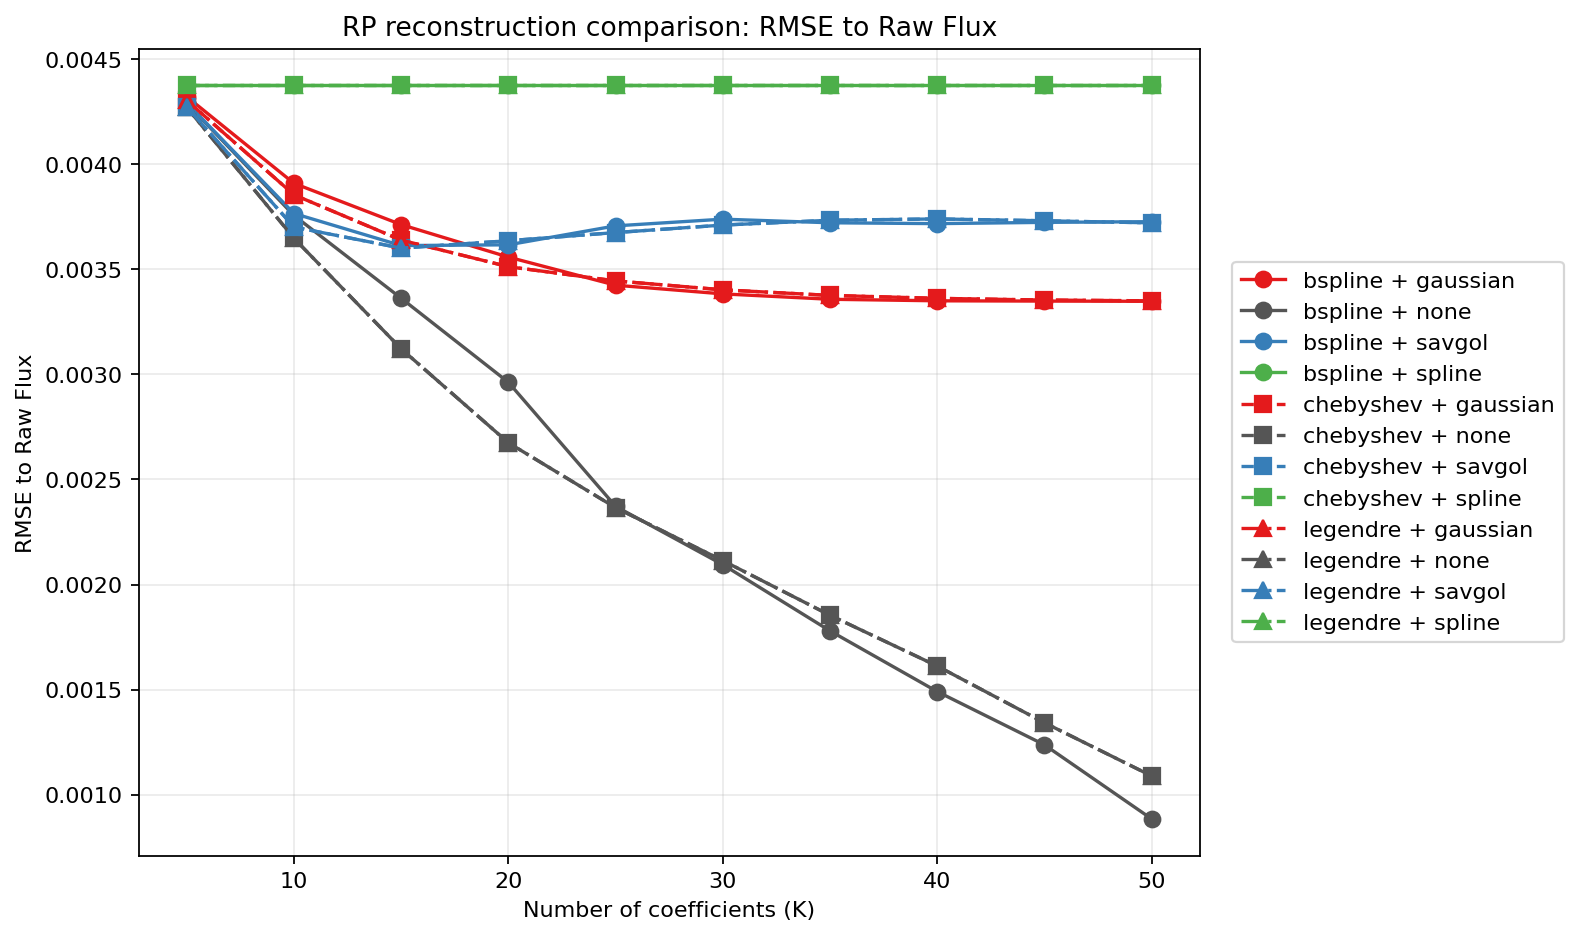

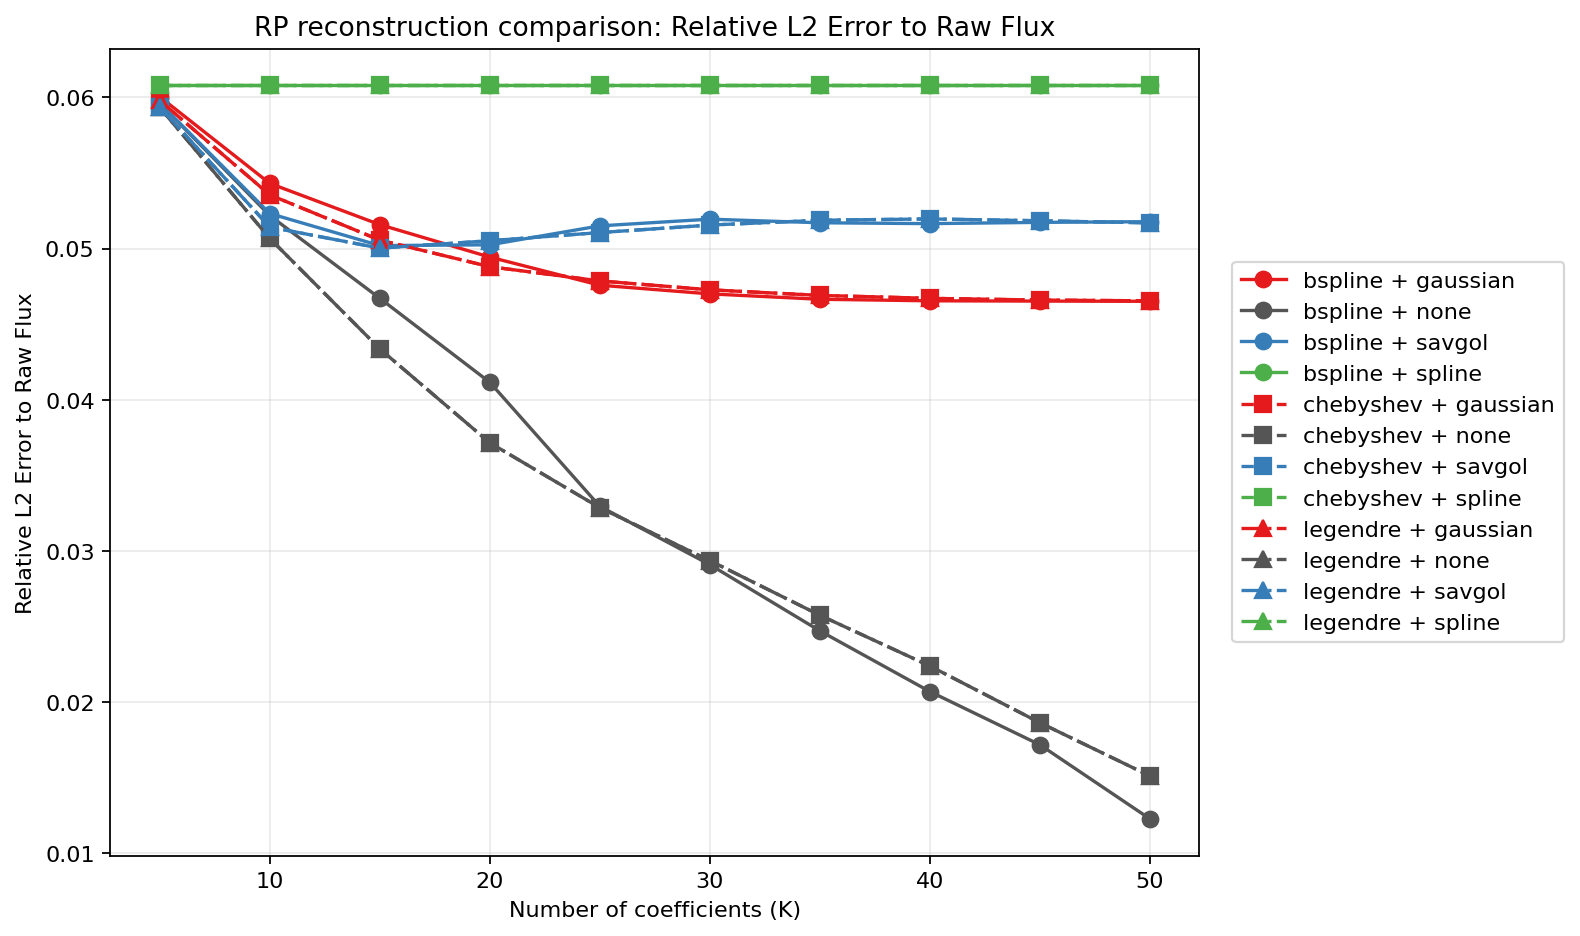

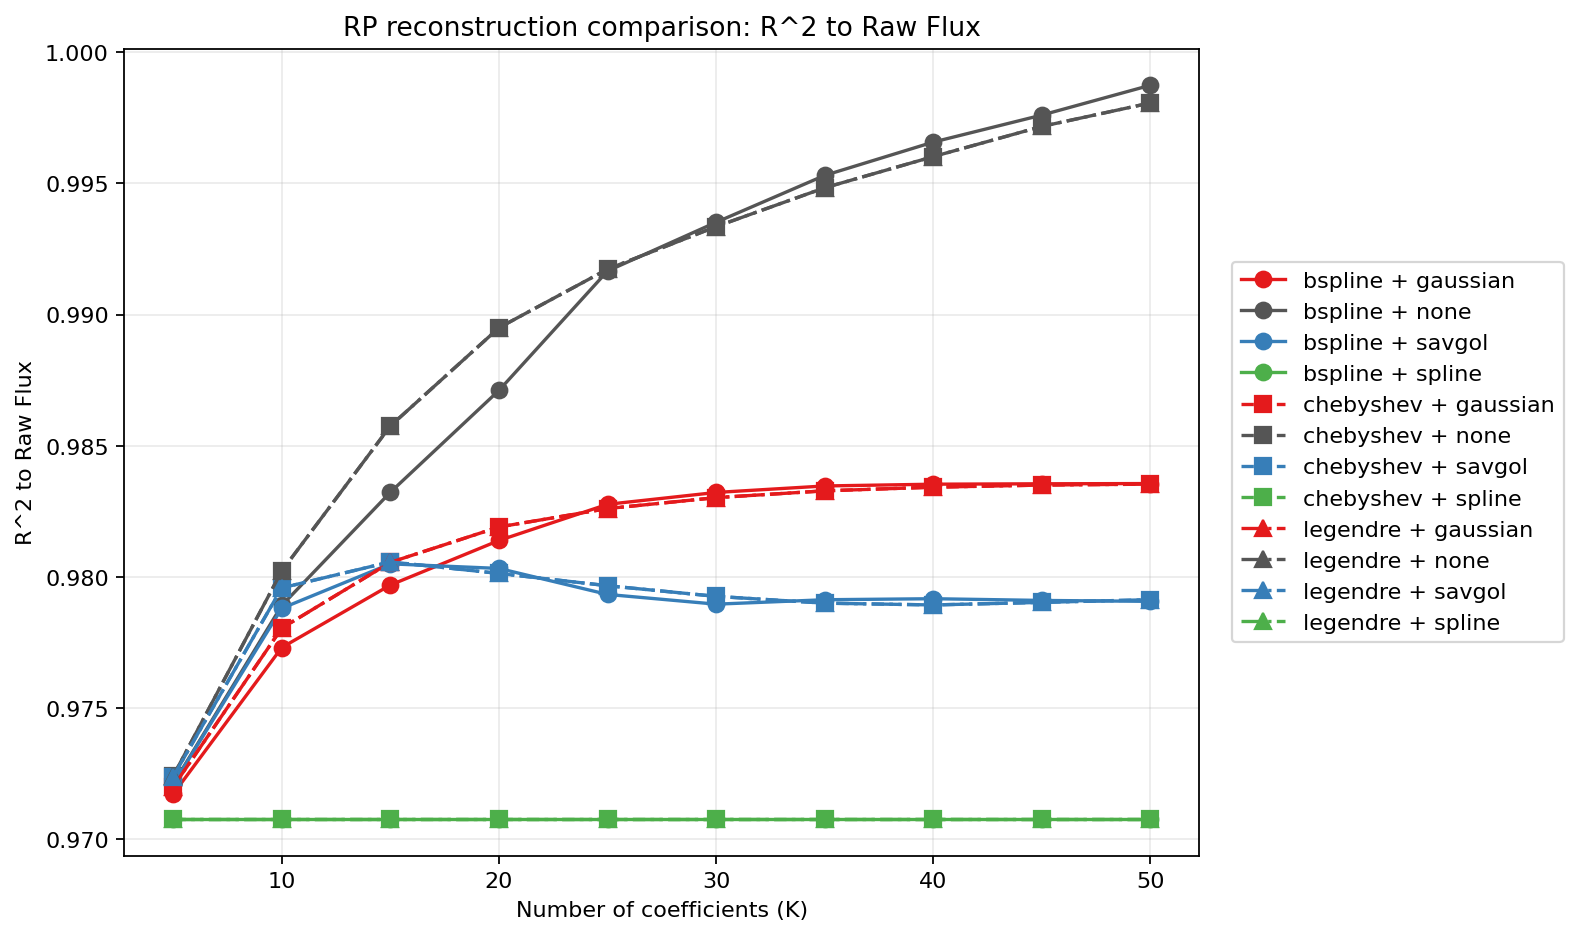

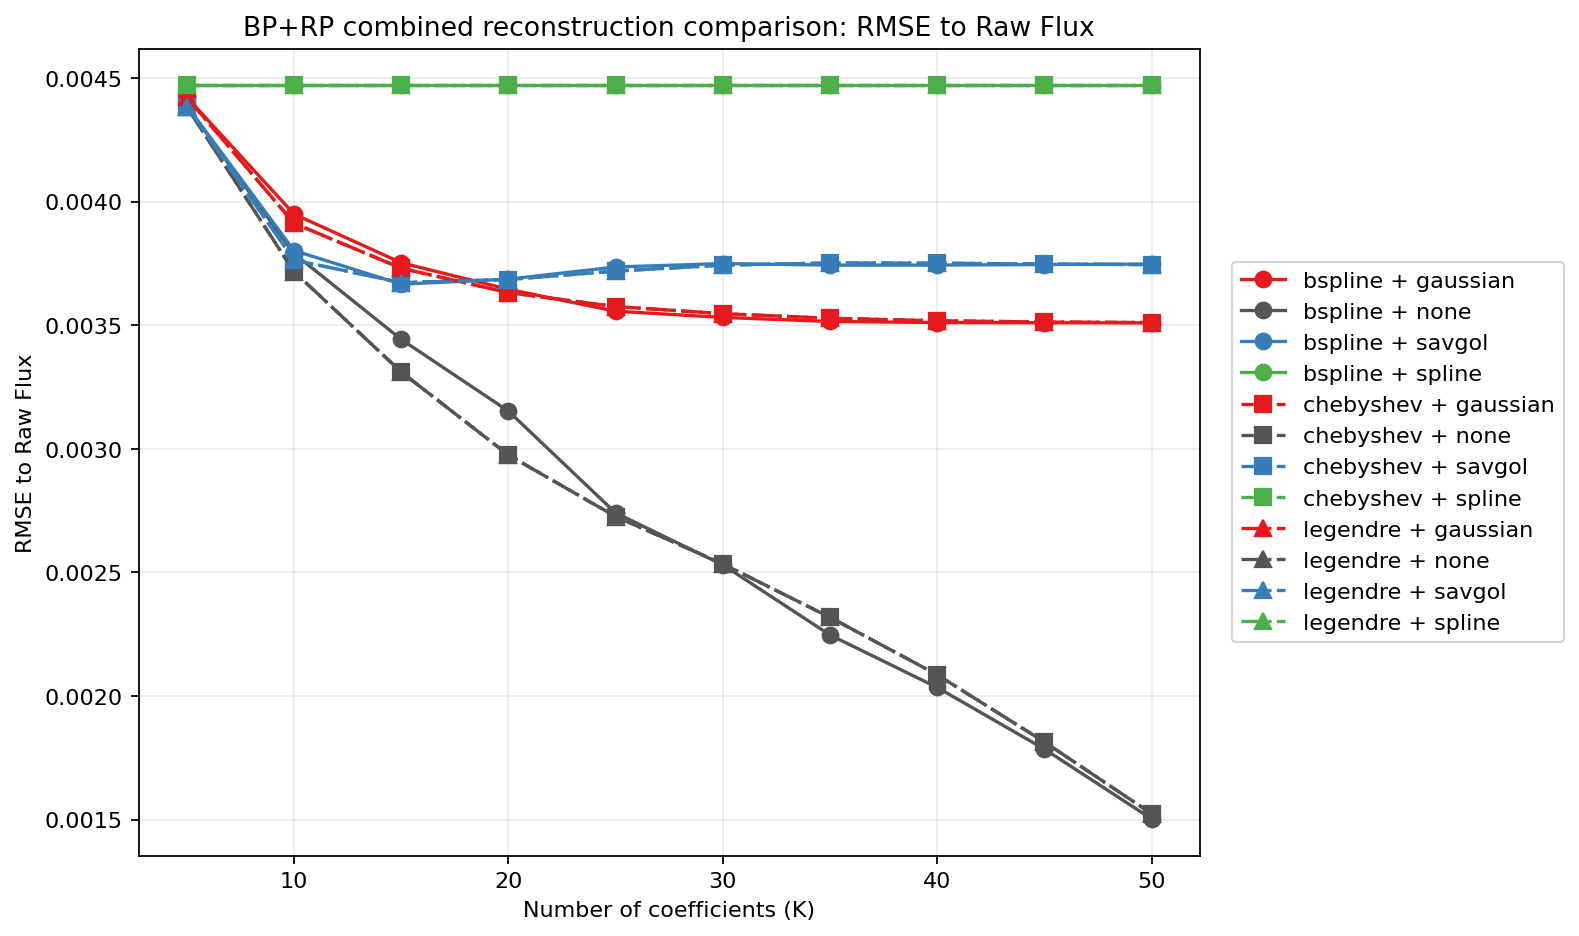

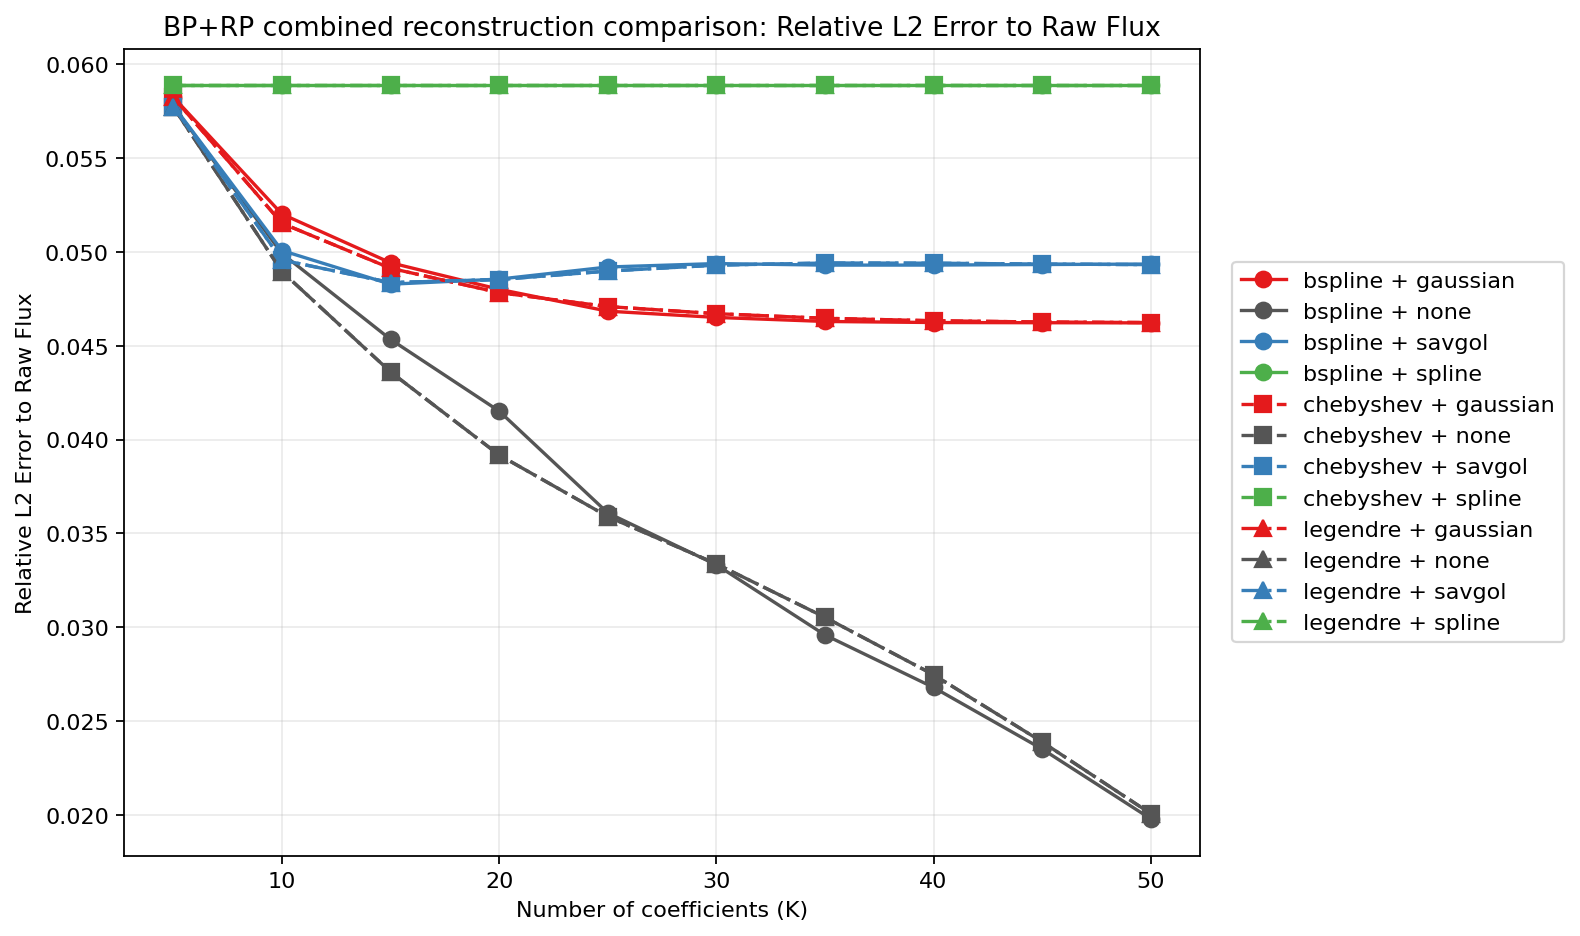

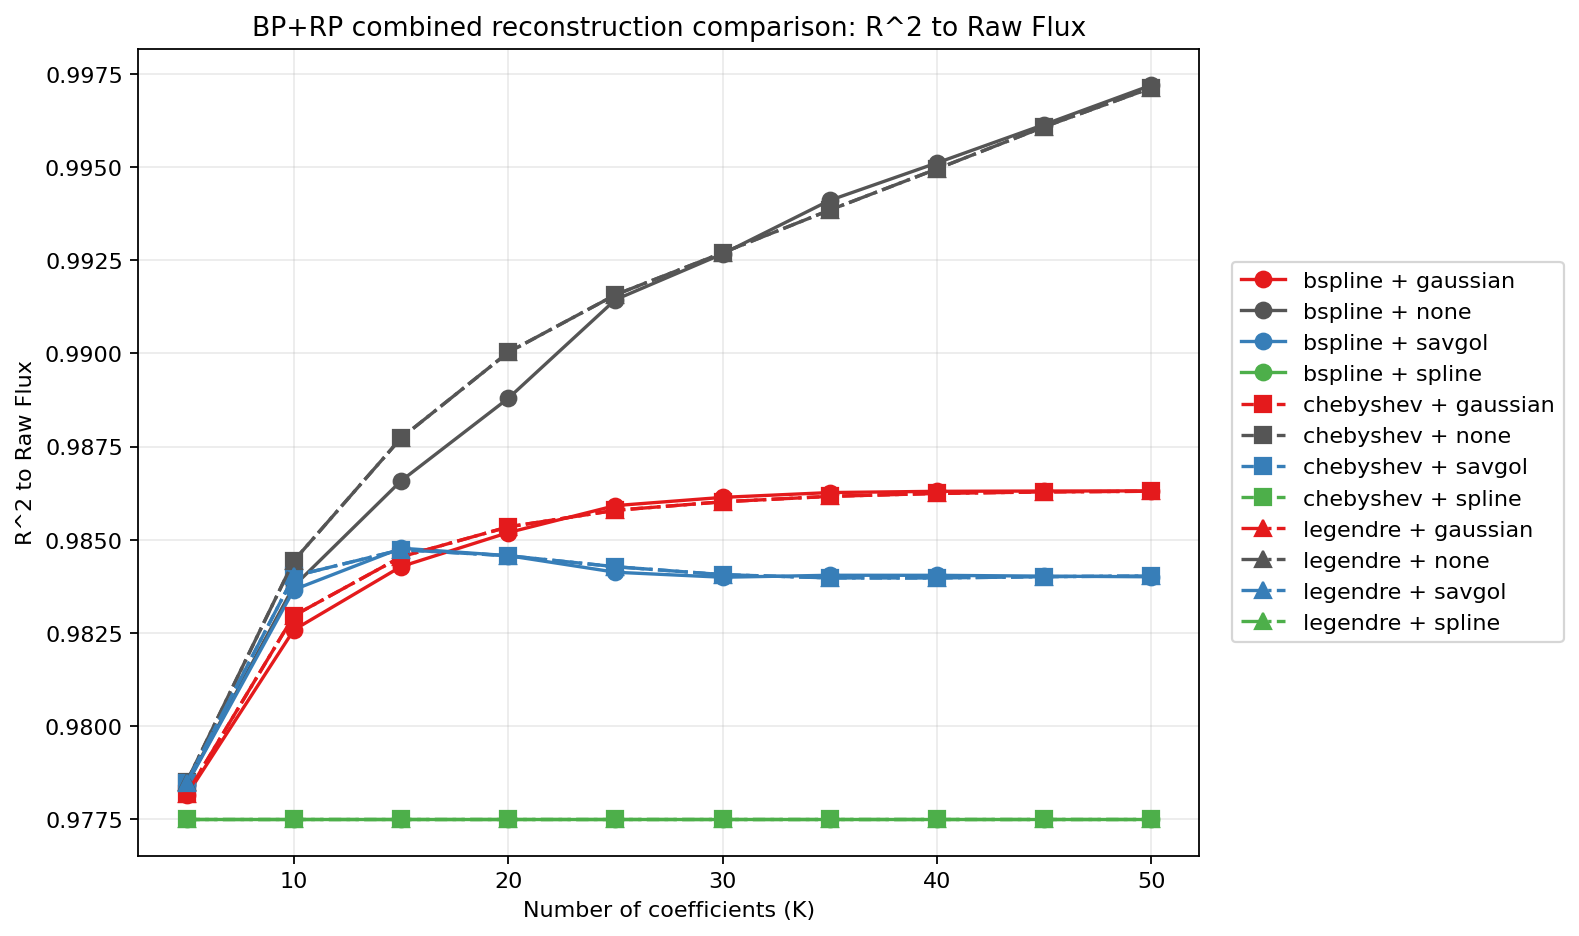

In [44]:
from IPython.display import display, Image as IPImage

metric_plots = step02.plot_metric_curves(summary, reconstruction_dir)
print("Saved metric plots:", [p.name for p in metric_plots])

for p in metric_plots:
    display(IPImage(filename=str(p)))

---
## Visual check: one star, all basis x smoothing combinations (K=20)

For a single randomly chosen star, show the raw BP/RP spectrum alongside the
smoothed and reconstructed curves for every basis and smoothing method.

Star index=251, source_id=662771594747150976, class=binary


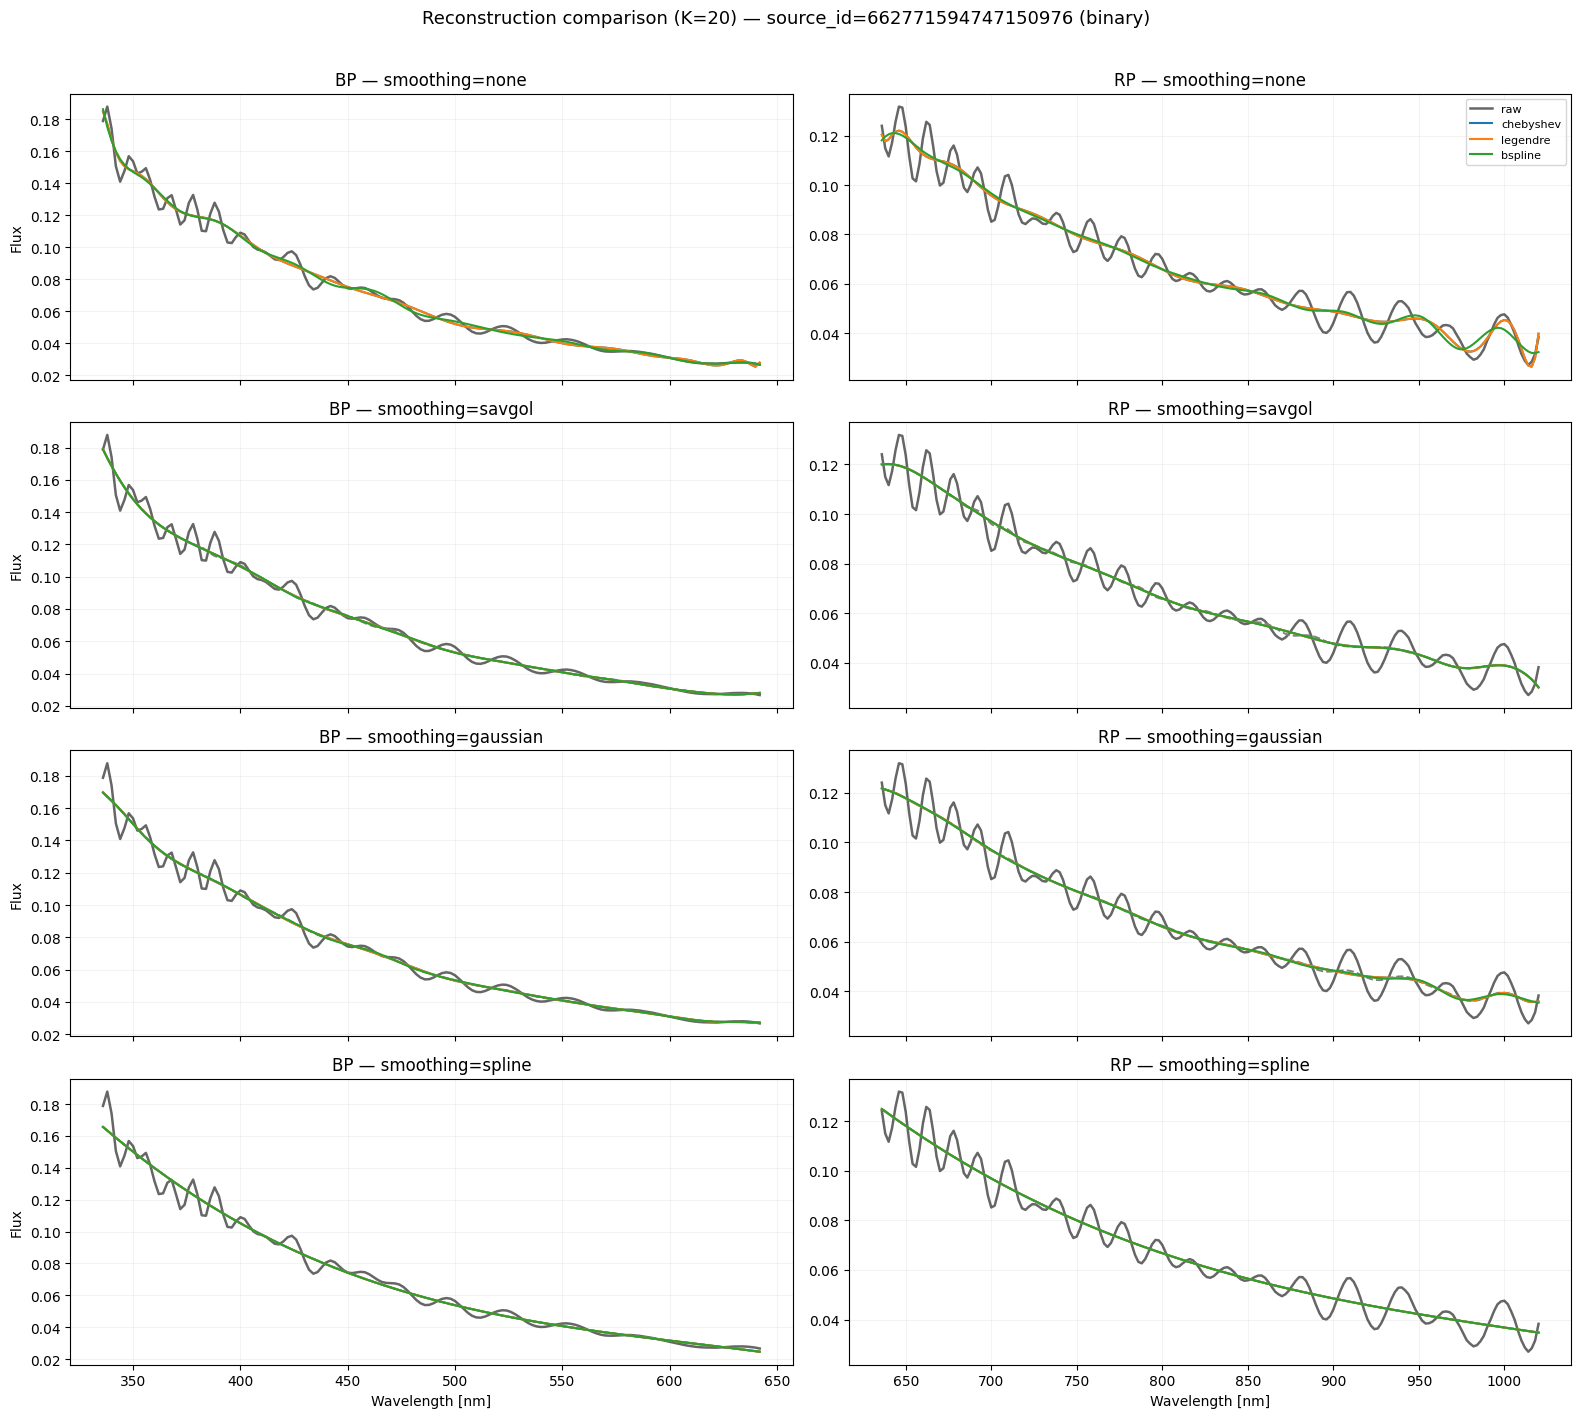

In [40]:
VIS_K = 20
bases = ["chebyshev", "legendre", "bspline"]
smoothing_configs = {"none": {}}
smoothing_configs.update(WINNING_PARAMS)

rng = np.random.default_rng(42)
star_idx = rng.integers(0, bp.flux.shape[0])
star_id = bp.source_ids[star_idx]
star_label = "binary" if bp.labels[star_idx] == 1 else "single"
print(f"Star index={star_idx}, source_id={star_id}, class={star_label}")

basis_colors = {"chebyshev": "#1f77b4", "legendre": "#ff7f0e", "bspline": "#2ca02c"}

fig, axes = plt.subplots(
    len(smoothing_configs), 2,
    figsize=(16, 3.5 * len(smoothing_configs)),
    sharex="col",
    squeeze=False,
)

for row_i, (smoothing, smooth_kwargs) in enumerate(smoothing_configs.items()):
    for col_i, (block, arm_label) in enumerate([(bp, "BP"), (rp, "RP")]):
        ax = axes[row_i, col_i]
        raw_flux = block.flux[star_idx]
        ax.plot(block.wavelengths, raw_flux, color="black", lw=1.8, alpha=0.6, label="raw")

        smoothed = step02.smooth_flux(raw_flux, smoothing, **smooth_kwargs)
        if smoothing != "none":
            ax.plot(block.wavelengths, smoothed, color="gray", lw=1.4, ls="--", label=f"smoothed ({smoothing})")

        for basis in bases:
            coeffs = step02.fit_basis(block.wavelengths, smoothed, basis, VIS_K)
            recon = step02.reconstruct_flux(block.wavelengths, coeffs, basis)
            ax.plot(block.wavelengths, recon, lw=1.5, color=basis_colors[basis], label=basis)

        ax.set_title(f"{arm_label} — smoothing={smoothing}")
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=8, loc="upper right")
        if row_i == len(smoothing_configs) - 1:
            ax.set_xlabel("Wavelength [nm]")
        if col_i == 0:
            ax.set_ylabel("Flux")
        ax.grid(alpha=0.15)

fig.suptitle(
    f"Reconstruction comparison (K={VIS_K}) — source_id={star_id} ({star_label})",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()